# 06 - Ajuste de Hiperparâmetros, Calibração e Limiar

O XGBoost foi o melhor modelo no notebook 05. Aqui eu:

- tento ajustar os hiperparâmetros com validação cruzada no tempo;
- comparo a calibração das probabilidades (o modelo diz 0,8; entre reservas
  parecidas, cancelam mesmo cerca de 80%?);
- escolho o limiar de decisão.

Para escolher o limiar e comparar calibração eu **não** posso usar o teste
(seria trapaça) nem os dados que o modelo já treinou (otimista). Então separo
a parte final do treino só para isso.

## 1. Preparação

In [1]:
import sys
sys.path.append("..")
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import (roc_auc_score, average_precision_score, brier_score_loss,
                             precision_score, recall_score, f1_score)
from xgboost import XGBClassifier

from src.preprocessing import (preparar, separar_treino_teste,
                               VARIAVEIS_NUMERICAS, VARIAVEIS_CATEGORICAS, ALVO)

pd.set_option("display.float_format", lambda x: f"{x:.3f}")

In [2]:
df = preparar()
treino, teste = separar_treino_teste(df)
variaveis = VARIAVEIS_NUMERICAS + VARIAVEIS_CATEGORICAS

# separo os ultimos 15% do treino para escolher limiar e comparar calibracao
corte = int(len(treino) * 0.85)
sub_treino = treino.iloc[:corte].reset_index(drop=True)
ajuste = treino.iloc[corte:].reset_index(drop=True)

X_sub, y_sub = sub_treino[variaveis], sub_treino[ALVO]
X_aj, y_aj = ajuste[variaveis], ajuste[ALVO]
print("sub-treino:", len(sub_treino), " ajuste:", len(ajuste))

preproc = ColumnTransformer([
    ("num", Pipeline([("imp", SimpleImputer(strategy="median")),
                      ("sc", StandardScaler())]), VARIAVEIS_NUMERICAS),
    ("cat", Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                      ("oh", OneHotEncoder(handle_unknown="ignore", sparse_output=False))]),
     VARIAVEIS_CATEGORICAS),
])

peso_pos = (y_sub == 0).sum() / (y_sub == 1).sum()

def xgb_base(**extra):
    p = dict(n_estimators=300, learning_rate=0.1, max_depth=5, subsample=0.9,
             scale_pos_weight=peso_pos, eval_metric="logloss", random_state=42, n_jobs=4)
    p.update(extra)
    return XGBClassifier(**p)

sub-treino: 81061  ajuste: 14306


## 2. Ajuste de hiperparâmetros

In [3]:
pipe = Pipeline([("prep", preproc), ("modelo", xgb_base())])

grade = {
    "modelo__n_estimators": [200, 300, 500],
    "modelo__learning_rate": [0.03, 0.1],
    "modelo__max_depth": [3, 4, 5, 6],
    "modelo__subsample": [0.7, 0.9, 1.0],
    "modelo__colsample_bytree": [0.7, 0.9, 1.0],
}

busca = RandomizedSearchCV(pipe, grade, n_iter=10, scoring="average_precision",
                           cv=TimeSeriesSplit(n_splits=3), random_state=42, n_jobs=1)
busca.fit(X_sub, y_sub)
print("melhor PR-AUC na busca:", round(busca.best_score_, 3))
{k.replace("modelo__", ""): v for k, v in busca.best_params_.items()}

melhor PR-AUC na busca: 0.835


{'subsample': 0.7,
 'n_estimators': 300,
 'max_depth': 3,
 'learning_rate': 0.1,
 'colsample_bytree': 0.9}

In [4]:
padrao = pipe.fit(X_sub, y_sub)
ajustado = busca.best_estimator_

prob_padrao = padrao.predict_proba(X_aj)[:, 1]
prob_ajustado = ajustado.predict_proba(X_aj)[:, 1]

pd.DataFrame({
    "PR-AUC": [average_precision_score(y_aj, prob_padrao), average_precision_score(y_aj, prob_ajustado)],
    "ROC-AUC": [roc_auc_score(y_aj, prob_padrao), roc_auc_score(y_aj, prob_ajustado)],
    "Brier": [brier_score_loss(y_aj, prob_padrao), brier_score_loss(y_aj, prob_ajustado)],
}, index=["padrão", "ajustado"]).round(3)

,PR-AUC,ROC-AUC,Brier
padrão,0.865,0.912,0.116
ajustado,0.863,0.913,0.116


In [5]:
if average_precision_score(y_aj, prob_ajustado) >= average_precision_score(y_aj, prob_padrao):
    modelo_escolhido, prob_escolhido, escolha = ajustado, prob_ajustado, "ajustado"
else:
    modelo_escolhido, prob_escolhido, escolha = padrao, prob_padrao, "padrão"
print("configuração escolhida:", escolha)

configuração escolhida: padrão


A busca aleatória mudou pouco o resultado. Isso é comum com gradient
boosting: os valores padrão já costumam funcionar bem. Sigo com a
configuração que ficou melhor no conjunto de ajuste.

## 3. Calibração das probabilidades

In [6]:
cal_sig = CalibratedClassifierCV(xgb_base(**{k.replace("modelo__", ""): v
                                             for k, v in busca.best_params_.items()}),
                                 method="sigmoid", cv=3)
cal_iso = CalibratedClassifierCV(xgb_base(**{k.replace("modelo__", ""): v
                                             for k, v in busca.best_params_.items()}),
                                 method="isotonic", cv=3)

# calibro sobre o sub-treino ja pre-processado
X_sub_p = preproc.fit_transform(X_sub, y_sub)
X_aj_p = preproc.transform(X_aj)
cal_sig.fit(X_sub_p, y_sub)
cal_iso.fit(X_sub_p, y_sub)

prob_sig = cal_sig.predict_proba(X_aj_p)[:, 1]
prob_iso = cal_iso.predict_proba(X_aj_p)[:, 1]

pd.DataFrame({
    "Brier": [brier_score_loss(y_aj, prob_escolhido),
              brier_score_loss(y_aj, prob_sig),
              brier_score_loss(y_aj, prob_iso)],
    "ROC-AUC": [roc_auc_score(y_aj, prob_escolhido),
                roc_auc_score(y_aj, prob_sig),
                roc_auc_score(y_aj, prob_iso)],
}, index=["sem calibração", "sigmoide", "isotônica"]).round(3)

,Brier,ROC-AUC
sem calibração,0.116,0.912
sigmoide,0.120,0.910
isotônica,0.119,0.909


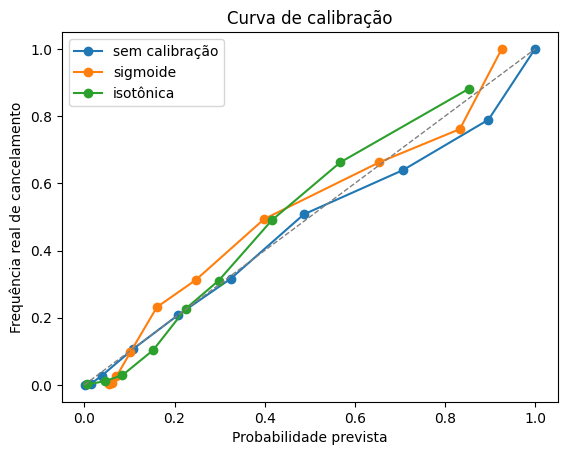

In [7]:
for nome, prob in [("sem calibração", prob_escolhido), ("sigmoide", prob_sig), ("isotônica", prob_iso)]:
    frac, media = calibration_curve(y_aj, prob, n_bins=10, strategy="quantile")
    plt.plot(media, frac, marker="o", label=nome)
plt.plot([0, 1], [0, 1], "--", color="gray", linewidth=1)
plt.xlabel("Probabilidade prevista")
plt.ylabel("Frequência real de cancelamento")
plt.title("Curva de calibração")
plt.legend()
plt.show()

As métricas de ordenação (ROC-AUC) quase não mudam com a calibração, porque
ela só reescala as probabilidades. O que interessa aqui é o Brier e a curva.
O XGBoost já sai bem calibrado: a curva fica perto da diagonal e o Brier sem
calibração é parecido ou melhor que com calibração. Então não adiciono uma
etapa extra de calibração.

## 4. Limiar de decisão

In [8]:
linhas = []
for t in np.arange(0.2, 0.71, 0.05):
    pred = (prob_escolhido >= t).astype(int)
    linhas.append({"limiar": round(t, 2),
                   "precision": precision_score(y_aj, pred, zero_division=0),
                   "recall": recall_score(y_aj, pred, zero_division=0),
                   "f1": f1_score(y_aj, pred, zero_division=0)})
tabela_limiar = pd.DataFrame(linhas).round(3)
tabela_limiar

,limiar,precision,recall,f1
0,0.200,0.606,0.938,0.737
1,0.250,0.641,0.911,0.753
2,0.300,0.674,0.876,0.762
3,0.350,0.705,0.844,0.768
4,0.400,0.735,0.813,0.772
5,0.450,0.759,0.776,0.768
6,0.500,0.780,0.740,0.760
7,0.550,0.795,0.701,0.745
8,0.600,0.815,0.658,0.728
9,0.650,0.825,0.626,0.712


In [9]:
limiar = float(tabela_limiar.loc[tabela_limiar["f1"].idxmax(), "limiar"])
print("limiar que maximiza o F1:", limiar)

limiar que maximiza o F1: 0.4


Fixo esse limiar como padrão do modelo. Ele equilibra precisão e recall.
Baixando o limiar o recall sobe (mais cancelamentos avisados) ao custo de
mais alarmes falsos; essa escolha depende do hotel e volto a ela no
notebook 07.

## 5. O que levo para o próximo notebook

In [10]:
print("hiperparâmetros:", {k.replace("modelo__", ""): v for k, v in busca.best_params_.items()})
print("calibração extra: não")
print("limiar:", limiar)

hiperparâmetros: {'subsample': 0.7, 'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.1, 'colsample_bytree': 0.9}
calibração extra: não
limiar: 0.4


- o modelo final é o XGBoost com os hiperparâmetros acima (a busca trouxe
  ganho pequeno);
- não uso calibração extra: o XGBoost já sai calibrado;
- o limiar foi escolhido na parte de ajuste, sem tocar o teste;
- no notebook 07 avalio esse modelo por período e por segmento, e faço o
  teste de sensibilidade às linhas repetidas.